In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/instagram.csv')
df.head()

,Influencer insta name,instagram name,category_1,category_2,Followers,Audience country(mostly),Authentic engagement\r\n,Engagement avg\r\n
0,433,433,Sports with a ball,NaN,48.5M,Spain,383.1K,637K
1,__youngbae__,TAEYANG,Music,NaN,12.7M,Indonesia,478K,542.3K
2,_agentgirl_,НАСТЯ ИВЛЕЕВА,Shows,NaN,18.8M,Russia,310.8K,377.9K
3,_imyour_joy,Joy,Lifestyle,NaN,13.5M,Indonesia,1.1M,1.4M
4,_jeongjaehyun,Jaehyun,NaN,NaN,11.1M,Indonesia,2.5M,3.1M


In [6]:
df.shape

(1000, 8)

In [7]:
df.dtypes

Influencer insta name       object
instagram name              object
category_1                  object
category_2                  object
Followers                   object
Audience country(mostly)    object
Authentic engagement\r\n    object
Engagement avg\r\n          object
dtype: object

In [8]:
df.isnull().sum()

Influencer insta name         0
instagram name               21
category_1                  108
category_2                  713
Followers                     0
Audience country(mostly)     14
Authentic engagement\r\n      0
Engagement avg\r\n            0
dtype: int64

In [9]:
df.describe()

,Influencer insta name,instagram name,category_1,category_2,Followers,Audience country(mostly),Authentic engagement\r\n,Engagement avg\r\n
count,1000,979,892,287,1000,986,1000,1000
unique,997,975,31,27,411,32,850,778
top,angelinajolie,Bruno Goes 🎭,Music,Cinema & Actors/actresses,6M,United States,1.1M,1.1M
freq,2,2,235,59,11,279,22,28


In [10]:
# Drop category_2 - too many missing values
df = df.drop(columns=['category_2'])

# Drop rows where country is missing
df = df.dropna(subset=['Audience country(mostly)'])

# Fill missing category_1 with 'Unknown'
df['category_1'] = df['category_1'].fillna('Unknown')

# Clean up messy column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace(r'\r\n', '', regex=True)

# Check it worked
df.columns

Index(['influencer_insta_name', 'instagram_name', 'category_1', 'followers',
       'audience_country(mostly)', 'authentic_engagement', 'engagement_avg'],
      dtype='object')

In [11]:
df = df.rename(columns={'audience_country(mostly)': 'country'})

# Confirm
df.columns

Index(['influencer_insta_name', 'instagram_name', 'category_1', 'followers',
       'country', 'authentic_engagement', 'engagement_avg'],
      dtype='object')

In [12]:
df.head()

,influencer_insta_name,instagram_name,category_1,followers,country,authentic_engagement,engagement_avg
0,433,433,Sports with a ball,48.5M,Spain,383.1K,637K
1,__youngbae__,TAEYANG,Music,12.7M,Indonesia,478K,542.3K
2,_agentgirl_,НАСТЯ ИВЛЕЕВА,Shows,18.8M,Russia,310.8K,377.9K
3,_imyour_joy,Joy,Lifestyle,13.5M,Indonesia,1.1M,1.4M
4,_jeongjaehyun,Jaehyun,Unknown,11.1M,Indonesia,2.5M,3.1M


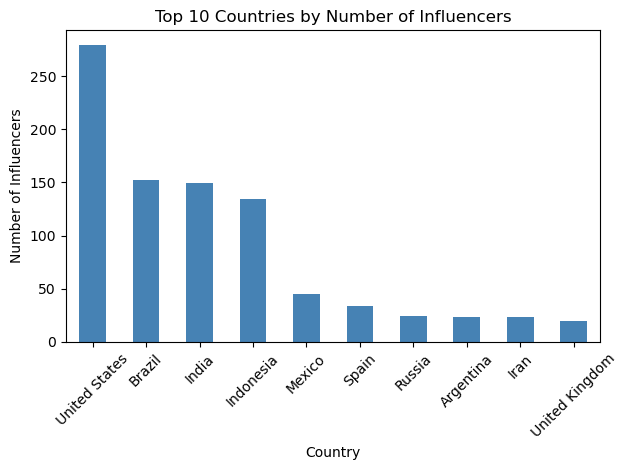

In [13]:
df['country'].value_counts().head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 Countries by Number of Influencers')
plt.xlabel('Country')
plt.ylabel('Number of Influencers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Finding 1 — Top Countries by Number of Influencers
The United States dominates the influencer space with nearly 280 influencers, 
almost double that of Brazil and India in second and third place. This suggests 
the US remains the largest market for social media influence, however the strong 
presence of Brazil, India and Indonesia highlights that influencer culture is 
truly global and not limited to Western markets.

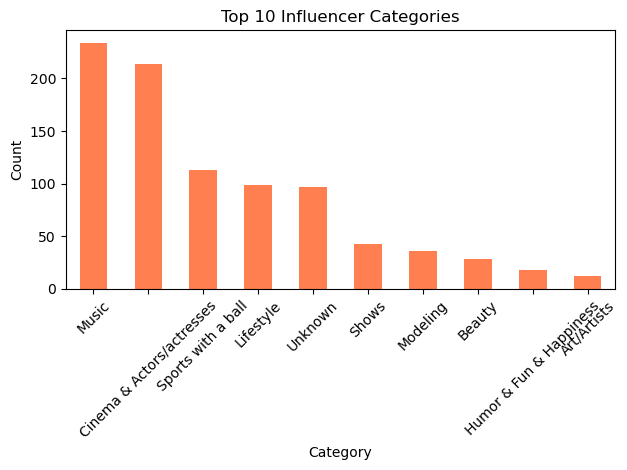

In [14]:
df['category_1'].value_counts().head(10).plot(kind='bar', color='coral')
plt.title('Top 10 Influencer Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Finding 2 — Top Influencer Categories
Music and Cinema & Actors/Actresses are by far the most common influencer 
categories on Instagram, with over 200 influencers each. Sports, Lifestyle 
and Entertainment follow behind. This suggests that entertainment-driven 
content dominates the influencer landscape, which aligns with Instagram's 
visually engaging and celebrity-driven culture.

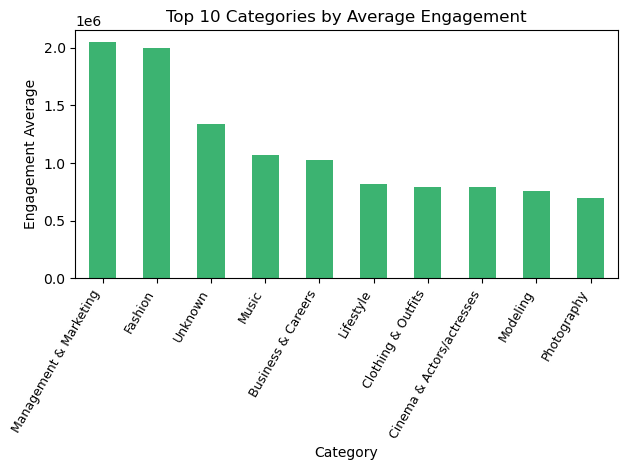

category_1
Management & Marketing       2.050000e+06
Fashion                      2.003344e+06
Unknown                      1.340587e+06
Music                        1.066800e+06
Business & Careers           1.022575e+06
Lifestyle                    8.181535e+05
Clothing & Outfits           7.906200e+05
Cinema & Actors/actresses    7.895888e+05
Modeling                     7.590750e+05
Photography                  6.958000e+05
Name: engagement_avg, dtype: float64


In [21]:
top_categories = df.groupby('category_1')['engagement_avg'].mean().sort_values(ascending=False).head(10)

top_categories.plot(kind='bar', color='mediumseagreen')
plt.title('Top 10 Categories by Average Engagement')
plt.xlabel('Category')
plt.ylabel('Engagement Average')
plt.xticks(rotation=60, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

# Also print them so we can read them clearly
print(top_categories)

# Finding 3 — Engagement by Category
Management & Marketing and Fashion are the top performing categories, averaging 
over 2 million engagements per post. This is nearly double the engagement of 
lower ranking categories like Photography and Modeling, suggesting that 
aspirational and career-driven content resonates most strongly with 
Instagram audiences.

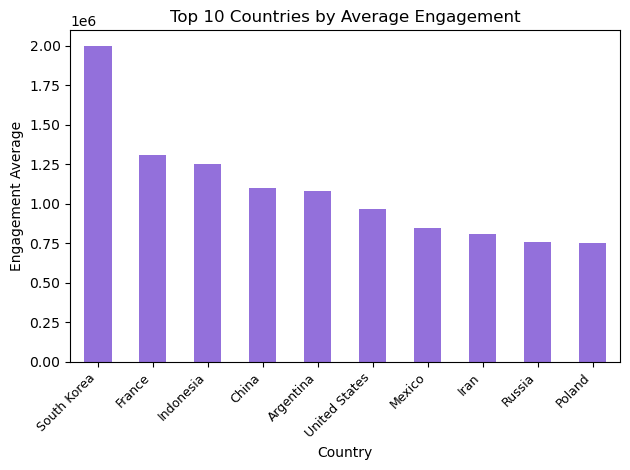

country
South Korea      1.997900e+06
France           1.305200e+06
Indonesia        1.253472e+06
China            1.100000e+06
Argentina        1.076974e+06
United States    9.653312e+05
Mexico           8.464644e+05
Iran             8.101913e+05
Russia           7.541125e+05
Poland           7.490000e+05
Name: engagement_avg, dtype: float64


In [22]:
top_countries = df.groupby('country')['engagement_avg'].mean().sort_values(ascending=False).head(10)

top_countries.plot(kind='bar', color='mediumpurple')
plt.title('Top 10 Countries by Average Engagement')
plt.xlabel('Country')
plt.ylabel('Engagement Average')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

print(top_countries)

# Finding 4 — Engagement by Country
South Korea leads all countries with an average engagement of nearly 2 million, 
significantly ahead of France and Indonesia in second and third place. 
Notably, South Korea and France outperform larger markets like the United 
States and Russia, suggesting that audience engagement is not purely 
driven by population size or number of influencers, but by the quality 
and cultural relevance of content.